# Лабораторная работа 7

**Сидимеков Дмитрий**

Цель - создать архитектуру многослойного персептрона, классифицирующего грибы из `mushroom_dataset`.

В этой работе используется датасет UCI Mushroom из `./data/agaricus-lepiota.data`. Все признаки категориальные, поэтому перед обучением они кодируются через one-hot encoding. Для бинарной классификации выбран 1 выходной нейрон с sigmoid: `p` (poisonous) кодируется как 1, `e` (edible) как 0

## Загрузка данных

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH = Path("data/agaricus-lepiota.data")

In [ ]:
# Имена столбцов взяты из agaricus-lepiota.names
attribute_names = [
    "class",
    "cap-shape",
    "cap-surface",
    "cap-color",
    "bruises",
    "odor",
    "gill-attachment",
    "gill-spacing",
    "gill-size",
    "gill-color",
    "stalk-shape",
    "stalk-root",
    "stalk-surface-above-ring",
    "stalk-surface-below-ring",
    "stalk-color-above-ring",
    "stalk-color-below-ring",
    "veil-type",
    "veil-color",
    "ring-number",
    "ring-type",
    "spore-print-color",
    "population",
    "habitat",
]

df = pd.read_csv(DATA_PATH, header=None, names=attribute_names)

print(f"Размер датасета: {df.shape[0]} объектов, {df.shape[1] - 1} признака")
print("Распределение классов:")
print(df["class"].value_counts())

df.head()

Размер датасета: 8124 объектов, 22 признака
Распределение классов:
class
e    4208
p    3916
Name: count, dtype: int64


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [ ]:
# y: poisonous -> 1, edible -> 0.
y = (df["class"] == "p").astype(int).to_numpy().reshape(-1, 1)

# X: все признаки категориальные, поэтому используем one-hot encoding
# Символ '?' в stalk-root оставляем отдельной категорией, так как в описании датасета это missing value
X_raw = df.drop(columns="class")
X_encoded = pd.get_dummies(X_raw).astype(float)
X = X_encoded.to_numpy(dtype=float)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Количество one-hot признаков: {X_encoded.shape[1]}")

X_encoded.head()

X shape: (8124, 117)
y shape: (8124, 1)
Количество one-hot признаков: 117


,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_f,cap-surface_g,cap-surface_s,cap-surface_y,...,population_s,population_v,population_y,habitat_d,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
def stratified_train_val_test_split(y, train_size=0.70, val_size=0.15, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    y_flat = np.asarray(y).ravel()

    train_idx, val_idx, test_idx = [], [], []
    for cls in np.unique(y_flat):
        cls_idx = np.where(y_flat == cls)[0]
        rng.shuffle(cls_idx)

        n_train = int(len(cls_idx) * train_size)
        n_val = int(len(cls_idx) * val_size)

        train_idx.extend(cls_idx[:n_train])
        val_idx.extend(cls_idx[n_train:n_train + n_val])
        test_idx.extend(cls_idx[n_train + n_val:])

    train_idx = np.array(train_idx)
    val_idx = np.array(val_idx)
    test_idx = np.array(test_idx)

    rng.shuffle(train_idx)
    rng.shuffle(val_idx)
    rng.shuffle(test_idx)

    return train_idx, val_idx, test_idx


train_idx, val_idx, test_idx = stratified_train_val_test_split(y)

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print("Доли poisonous в выборках:")
print(f"train: {y_train.mean():.3f}, val: {y_val.mean():.3f}, test: {y_test.mean():.3f}")

Train: (5686, 117), Val: (1218, 117), Test: (1220, 117)
Доли poisonous в выборках:
train: 0.482, val: 0.482, test: 0.482


## Метрики и ROC-кривая

In [ ]:
def binary_accuracy_score(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    return float(np.mean(y_true == y_pred))


def precision_recall_f1(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )
    return precision, recall, f1


def classification_metrics(y_true, y_scores, threshold=0.5):
    y_pred = (np.asarray(y_scores).ravel() >= threshold).astype(int)
    y_true = np.asarray(y_true).ravel()

    accuracy = binary_accuracy_score(y_true, y_pred)
    precision, recall, f1 = precision_recall_f1(y_true, y_pred)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


def confusion_matrix_binary(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))

    return pd.DataFrame(
        [[tn, fp], [fn, tp]],
        index=["actual_0_edible", "actual_1_poisonous"],
        columns=["pred_0_edible", "pred_1_poisonous"],
    )

In [ ]:
def roc_curve_manual(y_true, y_scores, title="ROC curve for MLP"):
    y_true = np.asarray(y_true).ravel().astype(int)
    y_scores = np.asarray(y_scores).ravel()

    # Пороги идём от самого строгого к самому мягкому: FPR и TPR растут монотонно
    thresholds = [np.inf]
    thresholds.extend(np.sort(np.unique(y_scores))[::-1].tolist())
    thresholds.append(-np.inf)

    tprs, fprs = [], []
    for threshold in thresholds:
        y_pred = (y_scores >= threshold).astype(int)

        tp = np.sum((y_pred == 1) & (y_true == 1))
        tn = np.sum((y_pred == 0) & (y_true == 0))
        fn = np.sum((y_pred == 0) & (y_true == 1))
        fp = np.sum((y_pred == 1) & (y_true == 0))

        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

        tprs.append(tpr)
        fprs.append(fpr)

    fprs = np.array(fprs)
    tprs = np.array(tprs)

    if hasattr(np, "trapezoid"):
        auc = np.trapezoid(tprs, fprs)
    else:
        auc = np.trapz(tprs, fprs)

    plt.figure(figsize=(6, 5))
    plt.plot(fprs, tprs, label=f"MLP, AUC = {auc:.3f}")
    plt.plot([0, 1], [0, 1], "--", color="gray", label="random")
    plt.xlim(0.0, 1.0)
    plt.ylim(0.0, 1.0)
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    return auc

## Реализация MLP

Слои реализованы как маленькие модули с интерфейсом `__init__`, `forward`, `backward`, `step`

Архитектура сети: два скрытых слоя с sigmoid и один выходной sigmoid нейро

In [ ]:
class Linear:
    """Полносвязный слой: y = XW + b"""

    def __init__(self, in_features, out_features, seed=None):
        rng = np.random.default_rng(seed)
    
        limit = np.sqrt(6.0 / (in_features + out_features))
        self.W = rng.uniform(-limit, limit, size=(in_features, out_features))
        self.b = np.zeros((1, out_features))

        self.X = None
        self.dW = None
        self.db = None

    def forward(self, X):
        self.X = X
        return X @ self.W + self.b

    def backward(self, grad_output):
        # grad_output уже содержит усреднение по batch из функции потерь.
        self.dW = self.X.T @ grad_output
        self.db = np.sum(grad_output, axis=0, keepdims=True)
        return grad_output @ self.W.T

    def step(self, lr):
        self.W -= lr * self.dW
        self.b -= lr * self.db


class Sigmoid:
    """Сигмоидальная функция активации"""

    def __init__(self):
        self.output = None

    def forward(self, X):
        X = np.clip(X, -500, 500)
        self.output = 1.0 / (1.0 + np.exp(-X))
        return self.output

    def backward(self, grad_output):
        return grad_output * self.output * (1.0 - self.output)

    def step(self, lr):
        # У слоя активации нет обучаемых параметров.
        pass


class MLP:
    """Многослойный персептрон: Linear -> Sigmoid -> Linear -> Sigmoid -> Linear -> Sigmoid"""

    def __init__(self, input_dim, hidden_dim_1=32, hidden_dim_2=16, seed=RANDOM_STATE):
        rng = np.random.default_rng(seed)
        layer_seeds = rng.integers(0, 1_000_000, size=3)

        self.layers = [
            Linear(input_dim, hidden_dim_1, seed=int(layer_seeds[0])),
            Sigmoid(),
            Linear(hidden_dim_1, hidden_dim_2, seed=int(layer_seeds[1])),
            Sigmoid(),
            Linear(hidden_dim_2, 1, seed=int(layer_seeds[2])),
            Sigmoid(),
        ]

        self.history = {
            "train_loss": [],
            "val_loss": [],
            "train_acc": [],
            "val_acc": [],
            "train_f1": [],
            "val_f1": [],
        }

    def forward(self, X):
        output = X
        for layer in self.layers:
            output = layer.forward(output)
        return output

    def backward(self, grad_output):
        grad = grad_output
        for layer in reversed(self.layers):
            grad = layer.backward(grad)
        return grad

    def step(self, lr):
        for layer in self.layers:
            layer.step(lr)

    def predict_proba(self, X):
        return self.forward(X).ravel()

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

Linear(117, 32): 117 * 32 + 32 = 3776

Linear(32, 16):  32 * 16 + 16 = 528

Linear(16, 1):   16 * 1 + 1 = 17

4321 параметр

In [ ]:
def binary_cross_entropy(y_true, y_pred):
    """Binary cross-entropy и её градиент по выходу sigmoid"""
    y_true = np.asarray(y_true, dtype=float).reshape(-1, 1)
    y_pred = np.asarray(y_pred, dtype=float).reshape(-1, 1)

    eps = 1e-9
    y_pred_clipped = np.clip(y_pred, eps, 1.0 - eps)

    loss = -np.mean(
        y_true * np.log(y_pred_clipped) + (1.0 - y_true) * np.log(1.0 - y_pred_clipped)
    )

    # Производная BCE по вероятности y_pred
    grad = -(y_true / y_pred_clipped - (1.0 - y_true) / (1.0 - y_pred_clipped)) / len(
        y_true
    )

    return loss, grad


def iterate_minibatches(X, y, batch_size, rng):
    indices = rng.permutation(len(X))
    for start in range(0, len(X), batch_size):
        batch_idx = indices[start : start + batch_size]
        yield X[batch_idx], y[batch_idx]


def fit(
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=100,
    batch_size=128,
    lr=0.5,
    print_every=20,
    seed=RANDOM_STATE,
):
    rng = np.random.default_rng(seed)

    for epoch in range(1, epochs + 1):
        for X_batch, y_batch in iterate_minibatches(X_train, y_train, batch_size, rng):
            y_batch_proba = model.forward(X_batch)
            _, grad_loss = binary_cross_entropy(y_batch, y_batch_proba)
            model.backward(grad_loss)
            model.step(lr)

        train_proba = model.predict_proba(X_train)
        val_proba = model.predict_proba(X_val)

        train_loss, _ = binary_cross_entropy(y_train, train_proba)
        val_loss, _ = binary_cross_entropy(y_val, val_proba)

        train_metrics = classification_metrics(y_train, train_proba)
        val_metrics = classification_metrics(y_val, val_proba)

        model.history["train_loss"].append(train_loss)
        model.history["val_loss"].append(val_loss)
        model.history["train_acc"].append(train_metrics["accuracy"])
        model.history["val_acc"].append(val_metrics["accuracy"])
        model.history["train_f1"].append(train_metrics["f1"])
        model.history["val_f1"].append(val_metrics["f1"])

        if epoch == 1 or epoch % print_every == 0:
            print(
                f"Epoch {epoch:3d}: "
                f"train_loss={train_loss:.5f}, val_loss={val_loss:.5f}, "
                f"train_acc={train_metrics['accuracy']:.4f}, val_acc={val_metrics['accuracy']:.4f}, "
                f"train_f1={train_metrics['f1']:.4f}, val_f1={val_metrics['f1']:.4f}"
            )

    return model

## Обучение нейронной сети

In [9]:
model = MLP(
    input_dim=X_train.shape[1],
    hidden_dim_1=32,
    hidden_dim_2=16,
    seed=RANDOM_STATE,
)

model = fit(
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=100,
    batch_size=128,
    lr=0.5,
    print_every=20,
    seed=RANDOM_STATE,
)

Epoch   1: train_loss=0.53772, val_loss=0.53672, train_acc=0.8955, val_acc=0.8949, train_f1=0.8785, val_f1=0.8776


Epoch  20: train_loss=0.00425, val_loss=0.00551, train_acc=0.9995, val_acc=0.9975, train_f1=0.9995, val_f1=0.9974


Epoch  40: train_loss=0.00138, val_loss=0.00143, train_acc=1.0000, val_acc=1.0000, train_f1=1.0000, val_f1=1.0000


Epoch  60: train_loss=0.00076, val_loss=0.00074, train_acc=1.0000, val_acc=1.0000, train_f1=1.0000, val_f1=1.0000


Epoch  80: train_loss=0.00051, val_loss=0.00048, train_acc=1.0000, val_acc=1.0000, train_f1=1.0000, val_f1=1.0000


Epoch 100: train_loss=0.00038, val_loss=0.00035, train_acc=1.0000, val_acc=1.0000, train_f1=1.0000, val_f1=1.0000


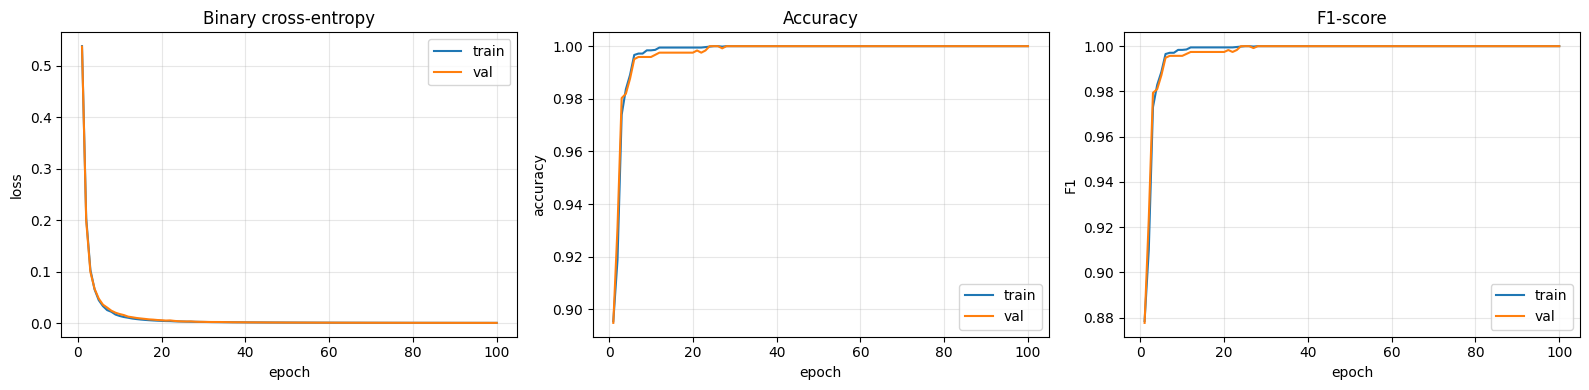

In [10]:
epochs = np.arange(1, len(model.history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(epochs, model.history["train_loss"], label="train")
axes[0].plot(epochs, model.history["val_loss"], label="val")
axes[0].set_title("Binary cross-entropy")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(epochs, model.history["train_acc"], label="train")
axes[1].plot(epochs, model.history["val_acc"], label="val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].grid(alpha=0.3)
axes[1].legend()

axes[2].plot(epochs, model.history["train_f1"], label="train")
axes[2].plot(epochs, model.history["val_f1"], label="val")
axes[2].set_title("F1-score")
axes[2].set_xlabel("epoch")
axes[2].set_ylabel("F1")
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

## Accuracy, precision, recall, F1-мера

In [11]:
y_test_scores = model.predict_proba(X_test)
y_test_pred = model.predict(X_test)

test_metrics = classification_metrics(y_test, y_test_scores, threshold=0.5)
metrics_df = pd.DataFrame(test_metrics, index=["MLP"])
metrics_df

,accuracy,precision,recall,f1
MLP,1.0,1.0,1.0,1.0


In [12]:
confusion_matrix_binary(y_test, y_test_pred)

,pred_0_edible,pred_1_poisonous
actual_0_edible,632,0
actual_1_poisonous,0,588


## ROC-кривая

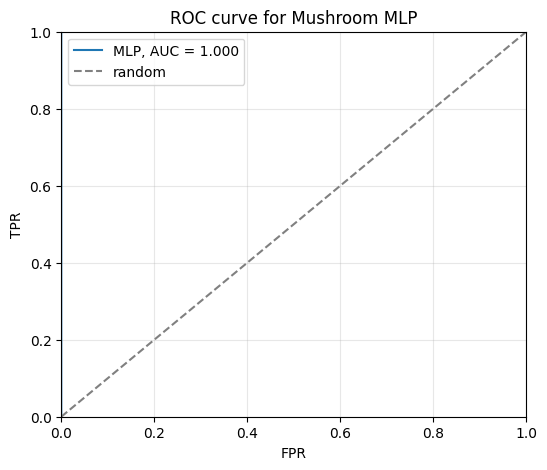

ROC-AUC = 1.000


In [13]:
auc = roc_curve_manual(y_test, y_test_scores, title="ROC curve for Mushroom MLP")
print(f"ROC-AUC = {auc:.3f}")